# 02 — Coverage summary by state and ZIP code

Summarize all Kroger-family records and the Kroger banner subset. The state and ZIP tables are also saved under `data/processed/`.

In [1]:
from pathlib import Path
import sys

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "scripts" / "build_all.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "scripts"))
ROOT

WindowsPath('D:/Healthy_food/Kroger_National_Coverage/kroger_national_coverage')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print('[1/5] Loading processed official API outputs...')
locations = pd.read_csv(ROOT / 'data' / 'processed' / 'kroger_family_locations.csv', dtype={'zip_code': 'string'})
state_summary = pd.read_csv(ROOT / 'data' / 'processed' / 'state_summary.csv')
zip_summary = pd.read_csv(ROOT / 'data' / 'processed' / 'zip_summary.csv', dtype={'zip_code': 'string'})
brand_summary = pd.read_csv(ROOT / 'data' / 'processed' / 'brand_summary.csv')
print(f'[2/5] Loaded {len(locations):,} locations, {len(state_summary)} states, {len(zip_summary):,} ZIP groups, and {len(brand_summary)} brands.')

[1/5] Loading processed official API outputs...
[2/5] Loaded 1,264 locations, 16 states, 1,023 ZIP groups, and 1 brands.


## National totals

In [3]:
print('[3/5] Calculating national totals...')
pd.Series({'all_family_locations': len(locations), 'active_locations': int(locations['status'].eq('active').sum()), 'inactive_locations': int(locations['status'].eq('inactive').sum()), 'unknown_status_locations': int(locations['status'].eq('unknown').sum()), 'kroger_banner_locations': int(locations['is_kroger_banner'].sum()), 'states': locations['state'].nunique(), 'zip_codes': locations['zip_code'].nunique(), 'brands': locations['brand'].nunique()}).to_frame('value')

[3/5] Calculating national totals...


,value
all_family_locations,1264
active_locations,1264
inactive_locations,0
unknown_status_locations,0
kroger_banner_locations,1264
states,16
zip_codes,1023
brands,1


Status is based on OpenStreetMap lifecycle tagging, not real-time verification with Kroger.

## State summary

In [4]:
state_summary.style.format({'locations': '{:,.0f}', 'kroger_banner_locations': '{:,.0f}', 'brands': '{:,.0f}'})

,state,locations,active_locations,inactive_locations,unknown_status_locations,kroger_banner_locations,brands
0,OH,209,209,0,0,209,1
1,TX,202,202,0,0,202,1
2,GA,166,166,0,0,166,1
3,MI,125,125,0,0,125,1
4,TN,119,119,0,0,119,1
5,KY,114,114,0,0,114,1
6,IN,103,103,0,0,103,1
7,VA,68,68,0,0,68,1
8,WV,37,37,0,0,37,1
9,MS,30,30,0,0,30,1


[4/5] Building the state coverage chart...
[4/5] State chart complete.


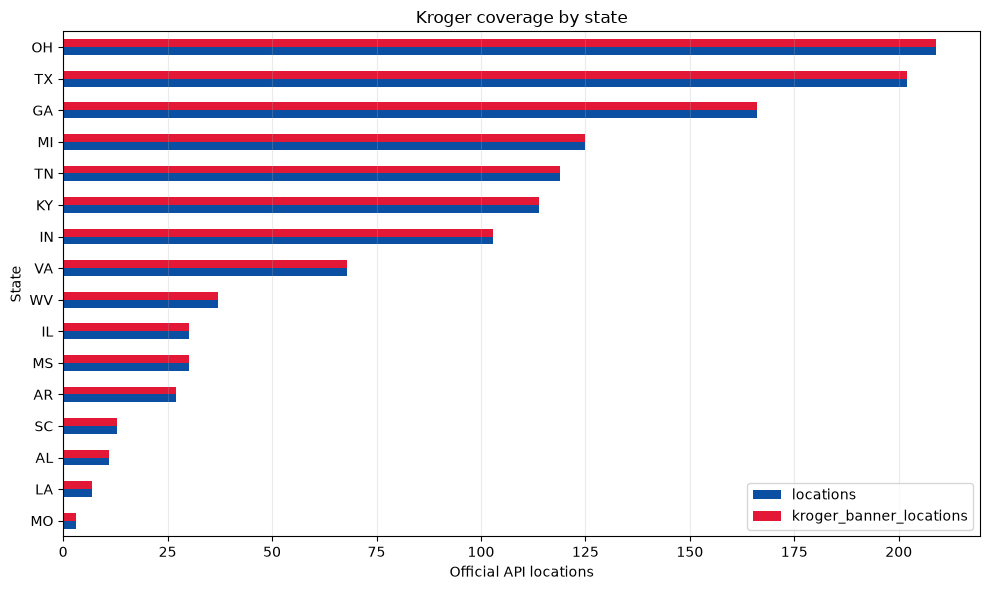

In [5]:
print('[4/5] Building the state coverage chart...')
plot_data = state_summary.sort_values('locations')
ax = plot_data.plot.barh(x='state', y=['locations','kroger_banner_locations'], figsize=(10, max(6, len(plot_data)*0.22)), color=['#0b4fa2','#e31837'])
ax.set(title='Kroger coverage by state', xlabel='Official API locations', ylabel='State')
ax.grid(axis='x', alpha=.25)
plt.tight_layout()
print('[4/5] State chart complete.')

## ZIP-code summary

`state` is included with ZIP to keep grouping unambiguous and easy to filter.

In [6]:
zip_summary.head(30)

,state,zip_code,locations,active_locations,inactive_locations,unknown_status_locations,kroger_banner_locations,brands
0,MI,48066,4,4,0,0,4,1
1,OH,45202,4,4,0,0,4,1
2,TN,37064,4,4,0,0,4,1
3,AR,71913,3,3,0,0,3,1
4,GA,30004,3,3,0,0,3,1
5,GA,30022,3,3,0,0,3,1
6,GA,30024,3,3,0,0,3,1
7,GA,30064,3,3,0,0,3,1
8,GA,31210,3,3,0,0,3,1
9,KY,40241,3,3,0,0,3,1


## Banner summary

In [7]:
print('[5/5] Coverage summary complete.')
brand_summary.head(30)

[5/5] Coverage summary complete.


,brand,locations,active_locations,inactive_locations,unknown_status_locations,states
0,KROGER,1264,1264,0,0,16
